In [248]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Normaliserer data


In [249]:
df0109_1 = pd.read_csv('../data/split/no_plug/0109-1.csv')
df1803 = pd.read_csv('../data/split/no_plug/1803.csv')
df2106_3 = pd.read_csv('../data/split/no_plug/2106-3.csv')
df2906_1 = pd.read_csv('../data/split/no_plug/2906-1.csv')
df3006_1 = pd.read_csv('../data/split/no_plug/3006-1.csv')
df3006_2 = pd.read_csv('../data/split/no_plug/3006-2.csv')
df0404 = pd.read_csv('../data/split/no_plug/0404.csv')
df0712 = pd.read_csv('../data/split/no_plug/0712.csv')
df1103 = pd.read_csv('../data/split/no_plug/1103.csv')
df2503 = pd.read_csv('../data/split/no_plug/2503.csv')

df0709 = pd.read_csv('../data/split/plug/0709.csv')
df2106_1 = pd.read_csv('../data/split/plug/2106-1.csv')
df2106_2 = pd.read_csv('../data/split/plug/2106-2.csv')
df2108_1 = pd.read_csv('../data/split/plug/2108-1.csv')
df2108_2 = pd.read_csv('../data/split/plug/2108-2.csv')
df2401_1 = pd.read_csv('../data/split/plug/2401-1.csv')
df2401_2 = pd.read_csv('../data/split/plug/2401-2.csv')
df2906_2 = pd.read_csv('../data/split/plug/2906-2.csv')
df2906_3 = pd.read_csv('../data/split/plug/2906-3.csv')
df2906_4 = pd.read_csv('../data/split/plug/2906-4.csv')
df3006_3 = pd.read_csv('../data/split/plug/3006-3.csv')
df0612_1 = pd.read_csv('../data/split/plug/0612-1.csv')
df0612_2 = pd.read_csv('../data/split/plug/0612-2.csv')
df0612_3 = pd.read_csv('../data/split/plug/0612-3.csv')
df0707_1 = pd.read_csv('../data/split/plug/0707-1.csv')
df0707_2 = pd.read_csv('../data/split/plug/0707-2.csv')
df0707_3 = pd.read_csv('../data/split/plug/0707-3.csv')
df0707_4 = pd.read_csv('../data/split/plug/0707-4.csv')
df1112 = pd.read_csv('../data/split/plug/1112.csv')
df1310_1 = pd.read_csv('../data/split/plug/1310-1.csv')
df1310_2 = pd.read_csv('../data/split/plug/1310-2.csv')
df1310_3 = pd.read_csv('../data/split/plug/1310-3.csv')
df1407_1 = pd.read_csv('../data/split/plug/1407-1.csv')
df1407_2 = pd.read_csv('../data/split/plug/1407-2.csv')
df1407_3 = pd.read_csv('../data/split/plug/1407-3.csv')
df1407_4 = pd.read_csv('../data/split/plug/1407-4.csv')
df1503 = pd.read_csv('../data/split/plug/1503.csv')
df1811 = pd.read_csv('../data/split/plug/1811.csv')
df2701 = pd.read_csv('../data/split/plug/2701.csv')

In [250]:
dfs = [df0109_1, df1803, df2106_3, df2906_1, df3006_1, df3006_2, df0404, df0712, df1103, df2503, df0709, df2106_1, df2106_2, df2108_1, df2108_2, df2401_1, df2401_2, df2906_2, df2906_3, df2906_4, df3006_3, df0612_1, df0612_2, df0612_3, df0707_1, df0707_2, df0707_3, df0707_4, df1112, df1310_1, df1310_2, df1310_3, df1407_1, df1407_2, df1407_3, df1407_4, df1503, df1811, df2701]

dfnames = ['0109-1', '1803', '2106-3', '2906-1', '3006-1', '3006-2', '0404', '0712', '1103', '2503', '0709', '2106-1', '2106-2', '2108-1', '2108-2', '2401-1', '2401-2', '2906-2', '2906-3', '2906-4', '3006-3', '0612-1', '0612-2', '0612-3', '0707-1', '0707-2', '0707-3', '0707-4', '1112', '1310-1', '1310-2', '1310-3', '1407-1', '1407-2', '1407-3', '1407-4', '1503', '1811', '2701']

Tar en tilfeldig df og ser om kolonnene matcher med de andre, de som ikke matcher, legges til i en liste

In [251]:
not_matching = []
not_matching_names = []
for i in range (len(dfs)):
    if(df3006_2.columns.equals(dfs[i].columns)):
        continue
    else:
        not_matching.append(dfs[i])
        not_matching_names.append(dfnames[i])

Sjekker om de mismatchende dfs matcher hverandre

In [252]:
for df in not_matching:
    print(df.columns == not_matching[0].columns)

[ True  True  True  True  True  True  True  True  True  True  True  True]
[ True  True  True  True  True  True  True  True  True  True  True  True]
[ True  True  True  True  True  True  True  True  True  True  True  True]
[ True  True  True  True  True  True  True  True  True  True  True  True]
[ True  True  True  True  True  True  True  True  True  True  True  True]


In [253]:
print(not_matching_names)

['0109-1', '0712', '2108-1', '2108-2', '1112']


Mapper navn på kolonner slik at de matcher hverandre

In [254]:
mapping = {
        'Pressure before pump (Arith. Mean)': 'Pump outlet pressure (Mean)',
        'Pressure after pump (Arith. Mean)': 'TS outlet pressure (Mean)',
        'Differential pressure (Arith. Mean)': 'Differential pressure (Mean)',
        'Flow rate (Arith. Mean)': 'Flow rate (Mean)',
        'Tank temperature (Arith. Mean)': 'Tank temperature (Mean)',
        'Temperature TS inlet (Arith. Mean)': 'Temperature TS inlet (Mean)',
        'Temperature TS outlet (Arith. Mean)': 'Temperature TS outlet (Mean)',
        'Bypass temperature (Arith. Mean)': 'Bypass temperature (Mean)'
    }
df0109_1 = df0109_1.rename(columns=mapping)
df2108_1 = df2108_1.rename(columns=mapping)
df2108_2 = df2108_2.rename(columns=mapping)
df1112 = df1112.rename(columns=mapping)
df0712 = df0712.rename(columns=mapping)

Legger til en diff pressure kolonne i hver df

In [255]:
dfs = [df0109_1, df1803, df2106_3, df2906_1, df3006_1, df3006_2, df0404, df0712, df1103, 
       df2503, df0709, df2106_1, df2106_2, df2108_1, df2108_2, df2401_1, df2401_2, df2906_2, 
       df2906_3, df2906_4, df3006_3, df0612_1, df0612_2, df0612_3, df0707_1, df0707_2, df0707_3, 
       df0707_4, df1112, df1310_1, df1310_2, df1310_3, df1407_1, df1407_2, df1407_3, df1407_4, df1503, df1811, df2701]

for df in dfs:
    if 'TS inlet pressure (Mean)' in df.columns:
        df['Differential pressure (Mean)'] = df['TS inlet pressure (Mean)'] - df['TS outlet pressure (Mean)']
        df['Total pressure drop'] = df['Pump outlet pressure (Mean)'] - df['TS inlet pressure (Mean)']
        df['resistance'] = df['Differential pressure (Mean)'] / (df['Flow rate (Mean)']**2)
    else:
        df['TS inlet pressure (Mean)'] = df['TS outlet pressure (Mean)'] + df['Differential pressure (Mean)']
        df['Total pressure drop'] = df['Pump outlet pressure (Mean)'] - df['TS inlet pressure (Mean)']
        df['resistance'] = df['Differential pressure (Mean)'] / (df['Flow rate (Mean)']**2)

In [256]:
no_plug_dfs = [df0109_1, df1803, df2106_3, df2906_1, df3006_1, df3006_2, df0404, df0712, df1103, df2503]

plug_dfs = [df0709, df2106_1, df2106_2, df2108_1, df2108_2, df2401_1, df2401_2, df2906_2, df2906_3, df2906_4, 
            df3006_3, df0612_1, df0612_2, df0612_3, df0707_1, df0707_2, df0707_3, df0707_4, df1112, df1310_1, 
            df1310_2, df1310_3, df1407_1, df1407_2, df1407_3, df1407_4, df1503, df1811, df2701]

Passer på at alle kolonnene er i samme rekkefølge i alle dfs

In [257]:
master_column_order = [
    'Time',
    'Temperature TS inlet (Mean)',
    'Temperature TS outlet (Mean)',
    'Tank temperature (Mean)',
    'Bypass temperature (Mean)',
    'Pump outlet pressure (Mean)',
    'TS inlet pressure (Mean)',
    'TS outlet pressure (Mean)',
    'Differential pressure (Mean)',
    'Total pressure drop',
    'Flow rate (Mean)',
    'reading_interval_s',
    'elapsed_runtime_s',
    'elapsed_runtime_m',
    'resistance'
]

In [258]:
standardized_plugs = []
standardized_no_plugs = []
for df in plug_dfs:
    df_reordered = df[master_column_order].copy()
    df_reordered = df_reordered.sort_values('elapsed_runtime_s').reset_index(drop=True)
    standardized_plugs.append(df_reordered)

for df in no_plug_dfs:
    df_reordered = df[master_column_order].copy()
    df_reordered = df_reordered.sort_values('elapsed_runtime_s').reset_index(drop=True)
    standardized_no_plugs.append(df_reordered)

Sanity check at alle kolonnene er like i alle dfs

In [259]:
for df in standardized_no_plugs:
    if(standardized_no_plugs[0].columns != df.columns).any():
        print('Mismatch!')
for df in standardized_plugs:
    if(standardized_plugs[0].columns != df.columns).any():
        print('Mismatch!')

In [293]:
def label_plug_runs(df, threshold, smooth_window, min_baseline_rows, max_baseline_rows, percentage_baseline, persistence, base):
    
    baseline_rows = min(max(min_baseline_rows, int(len(df) * percentage_baseline)), max_baseline_rows)
    
    baseline_res = df['resistance'].iloc[:baseline_rows].median()
    df['Relative_Resistance'] = df['resistance'] / baseline_res

    baseline_dp = df['Differential pressure (Mean)'].iloc[:baseline_rows].median()
    df['Relative_DP'] = df ['Differential pressure (Mean)'] / baseline_dp
  
    smoothed_dp = df[base].rolling(window=smooth_window).mean()

    is_above = (smoothed_dp > threshold).astype(int)
    roll_sum = is_above.rolling(window=persistence).sum() 
    
    potential_triggers = (roll_sum[baseline_rows:] >= persistence)
    
    tmpdf = df.copy()
    if potential_triggers.any():
        trigger_index = potential_triggers.idxmax()
        tmpdf['Plug_Label'] = 0
        tmpdf.loc[trigger_index:, 'Plug_Label'] = 1
    else:
        tmpdf['Plug_Label'] = 0
        
    return tmpdf

In [261]:
threshold_options = [1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2]
window_options = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
min_options = [10, 20, 30, 35, 40, 45, 50, 60]
max_options = [100, 125, 150, 300]
percentage_baseline = [0.05, 0.1, 0.15, 0.2]
persistence = [3, 5, 7, 10]
base = ['Relative_Resistance', 'resistance', 'Relative_DP', 'Differential pressure (Mean)']

optimization_results = []

for t in threshold_options:
    for w in window_options:
        for min_b in min_options:
            for max_b in max_options:
                for percentage in percentage_baseline:
                    for persist in persistence:
                        for b in base:
                            false_positives = 0
                            plugs_found = 0
                            
                            for df in no_plug_dfs:
                                labeled = label_plug_runs(df, t, w, min_b, max_b, percentage, persist, b)
                                if labeled['Plug_Label'].sum() > 0:
                                    false_positives += 1
                        
                            for df in plug_dfs:
                                labeled = label_plug_runs(df, t, w, min_b, max_b, percentage, persist, b)
                                if labeled['Plug_Label'].sum() > 0:
                                    plugs_found += 1
                            
                            optimization_results.append({
                                'Threshold': t,
                                'Window': w,
                                'False_Positives': false_positives,
                                'Plugs_Found': plugs_found,
                                'Min_Baseline_Rows': min_b,
                                'Max_Baseline_Rows': max_b,
                                'Percentage': percentage,
                                'Persistence': persist,
                                'Baseline': b
                            })

In [ ]:
opt_df = pd.DataFrame(optimization_results)
#opt_df = opt_df[opt_df['False_Positives'] != 0]
#opt_df = opt_df[opt_df['False_Positives'] != 1]
#opt_df = opt_df[opt_df['False_Positives'] != 2]
#opt_df = opt_df[opt_df['False_Positives'] != 3]
#opt_df = opt_df[opt_df['False_Positives'] != 4]
#opt_df = opt_df[opt_df['False_Positives'] != 5]
#opt_df = opt_df[opt_df['False_Positives'] != 6]

best_possible = opt_df.sort_values(
    
    by=['False_Positives', 'Plugs_Found', 'Threshold', 'Window', 'Persistence'],
    ascending=[True, False, True, False, False]
).head(10)

print("\n TOP 10 OPTIMAL SETTINGS")
print(best_possible.to_string(index=False))


 TOP 10 OPTIMAL SETTINGS
 Threshold  Window  False_Positives  Plugs_Found  Min_Baseline_Rows  Max_Baseline_Rows  Percentage  Persistence    Baseline
       1.7      15                1           14                 10                150         0.1           10 Relative_DP
       1.7      15                1           14                 10                150         0.1            7 Relative_DP
       1.7      15                1           14                 10                125         0.1            5 Relative_DP
       1.7      15                1           14                 10                150         0.1            5 Relative_DP
       1.7      15                1           14                 10                125         0.1            3 Relative_DP
       1.7      15                1           14                 10                150         0.1            3 Relative_DP
       1.7      14                1           14                 10                150         0.1        

In [330]:
best = []
opt_df = pd.DataFrame(optimization_results)

for i in range(7):
    current_subset = opt_df[opt_df['False_Positives'] == i]
    
    if not current_subset.empty:
        best_possible = current_subset.sort_values(
            by=['Plugs_Found', 'Threshold', 'Window', 'Persistence'],
            ascending=[False, True, False, False]
        )
    
    best.append(best_possible.iloc[[0]])

best_results = pd.concat(best, ignore_index=True)

In [329]:
best_results.head(10)

,Threshold,Window,False_Positives,Plugs_Found,Min_Baseline_Rows,Max_Baseline_Rows,Percentage,Persistence,Baseline
0,1.7,15,0,14,10,100,0.10,10,Relative_DP
1,1.7,15,1,14,10,150,0.10,10,Relative_DP
2,1.9,3,2,16,10,150,0.05,7,Relative_Resistance
3,2.0,11,3,19,10,100,0.05,3,Relative_Resistance
4,2.0,6,4,22,10,100,0.05,3,Relative_Resistance
5,1.7,3,5,27,10,100,0.05,3,Relative_Resistance
6,1.2,12,6,29,10,150,0.10,3,Relative_Resistance
7,1.2,12,6,29,10,150,0.10,3,Relative_Resistance


In [294]:
plug_dfs_labeled = [label_plug_runs(df, 1.7, 11, 10, 100, 0.05, 7, 'Relative_Resistance') for df in plug_dfs]
no_plug_dfs_labeled = [label_plug_runs(df, 1.7, 11, 10, 100, 0.05, 7, 'Relative_Resistance') for df in no_plug_dfs]

In [287]:
def plot_smoothed_plug_trends(dfs):
    num_plots = len(dfs)
    cols = 2
    rows = (num_plots + 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
    axes = axes.flatten()

    for i, df in enumerate(dfs):
        ax = axes[i]
        
        x_values = df['elapsed_runtime_s']
        
        ax.plot(x_values, df['Relative_Resistance'], 
                color='lightgray', alpha=0.8, label='Raw Sensor Data', linewidth=1)

        smoothed_trend = df['Relative_Resistance'].rolling(window=5).mean()
        
        ax.plot(x_values, smoothed_trend, 
                color='blue', label='Smoothed Trend', linewidth=2.5)
        
        if 'Plug_Label' in df.columns and (df['Plug_Label'] == 1).any():
            transition_time = df.loc[df['Plug_Label'] == 1, 'elapsed_runtime_s'].min()
            
            ax.axvline(x=transition_time, color='darkred', linestyle='--', linewidth=2)
            
            ax.fill_between(x_values, 
                            #df['Differential pressure (Mean)'].min(), 
                            #df['Differential pressure (Mean)'].max(),
                            df['Relative_Resistance'].min(), 
                            df['Relative_Resistance'].max(),   
                            where=(df['Plug_Label'] == 1), 
                            color='red', alpha=0.07)

        ax.set_title(f"Run #{i+1}: Development of Pressure Drop", fontsize=14, fontweight='bold')
        ax.set_ylabel("Pressure Drop (bar)")
        ax.set_xlabel("Elapsed runtime (seconds)")
        ax.grid(True, linestyle=':', alpha=0.6)
        if i == 0: ax.legend(loc='upper left')

    for j in range(i + 1, len(axes)): axes[j].axis('off')
    plt.tight_layout()
    plt.show()

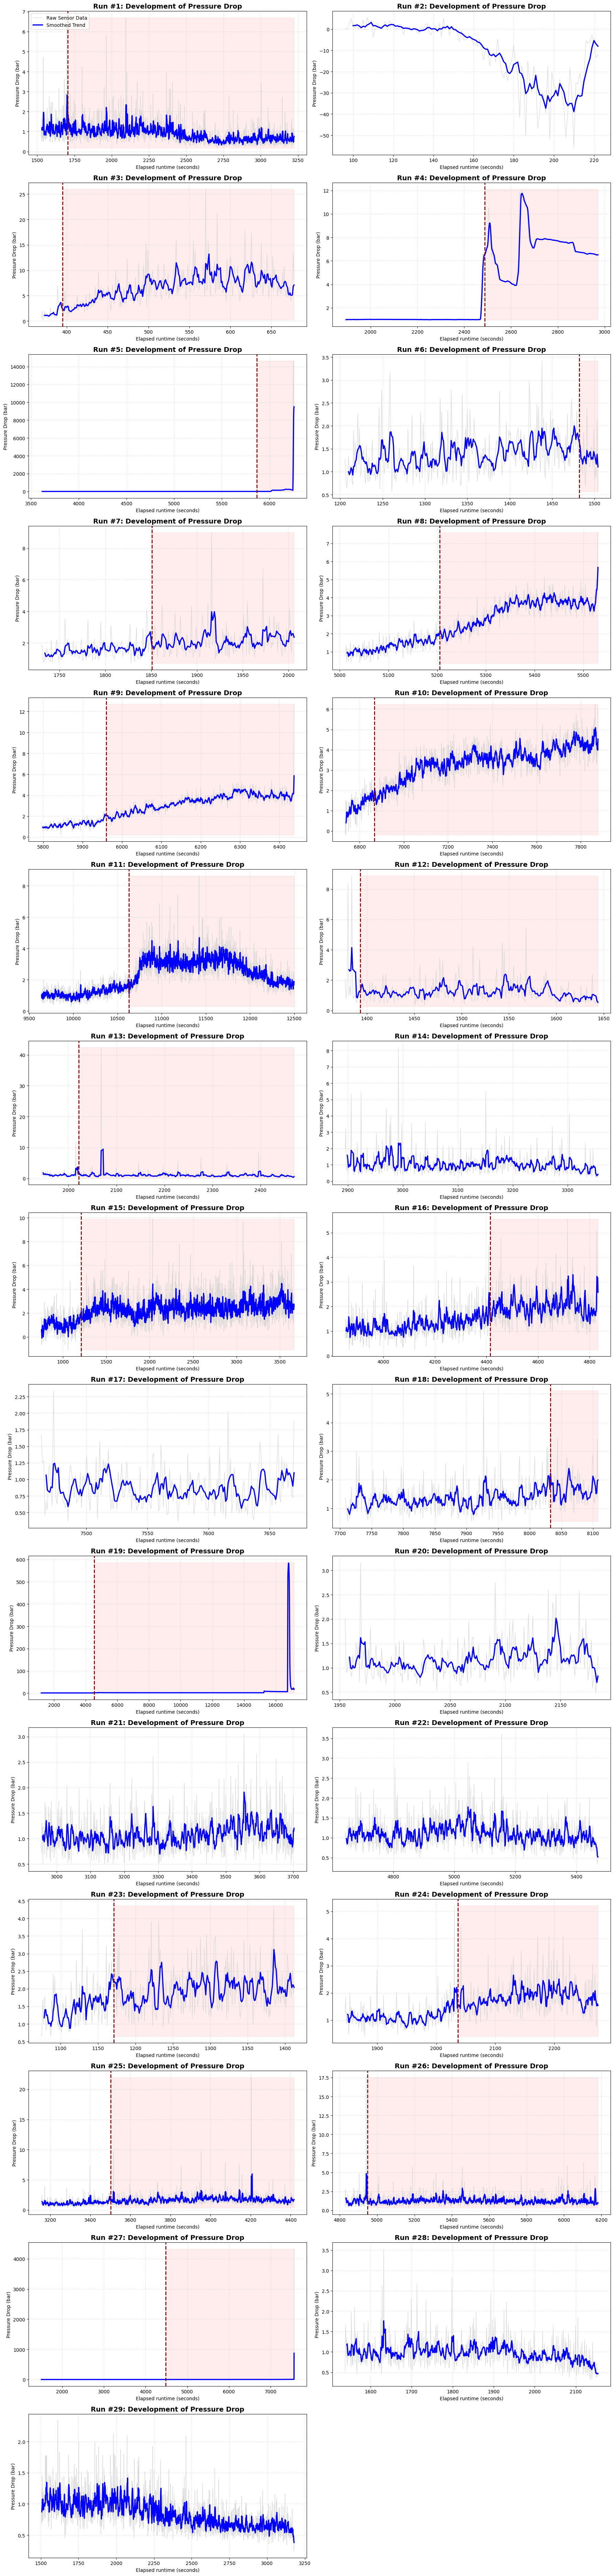

In [295]:
plot_smoothed_plug_trends(plug_dfs_labeled)

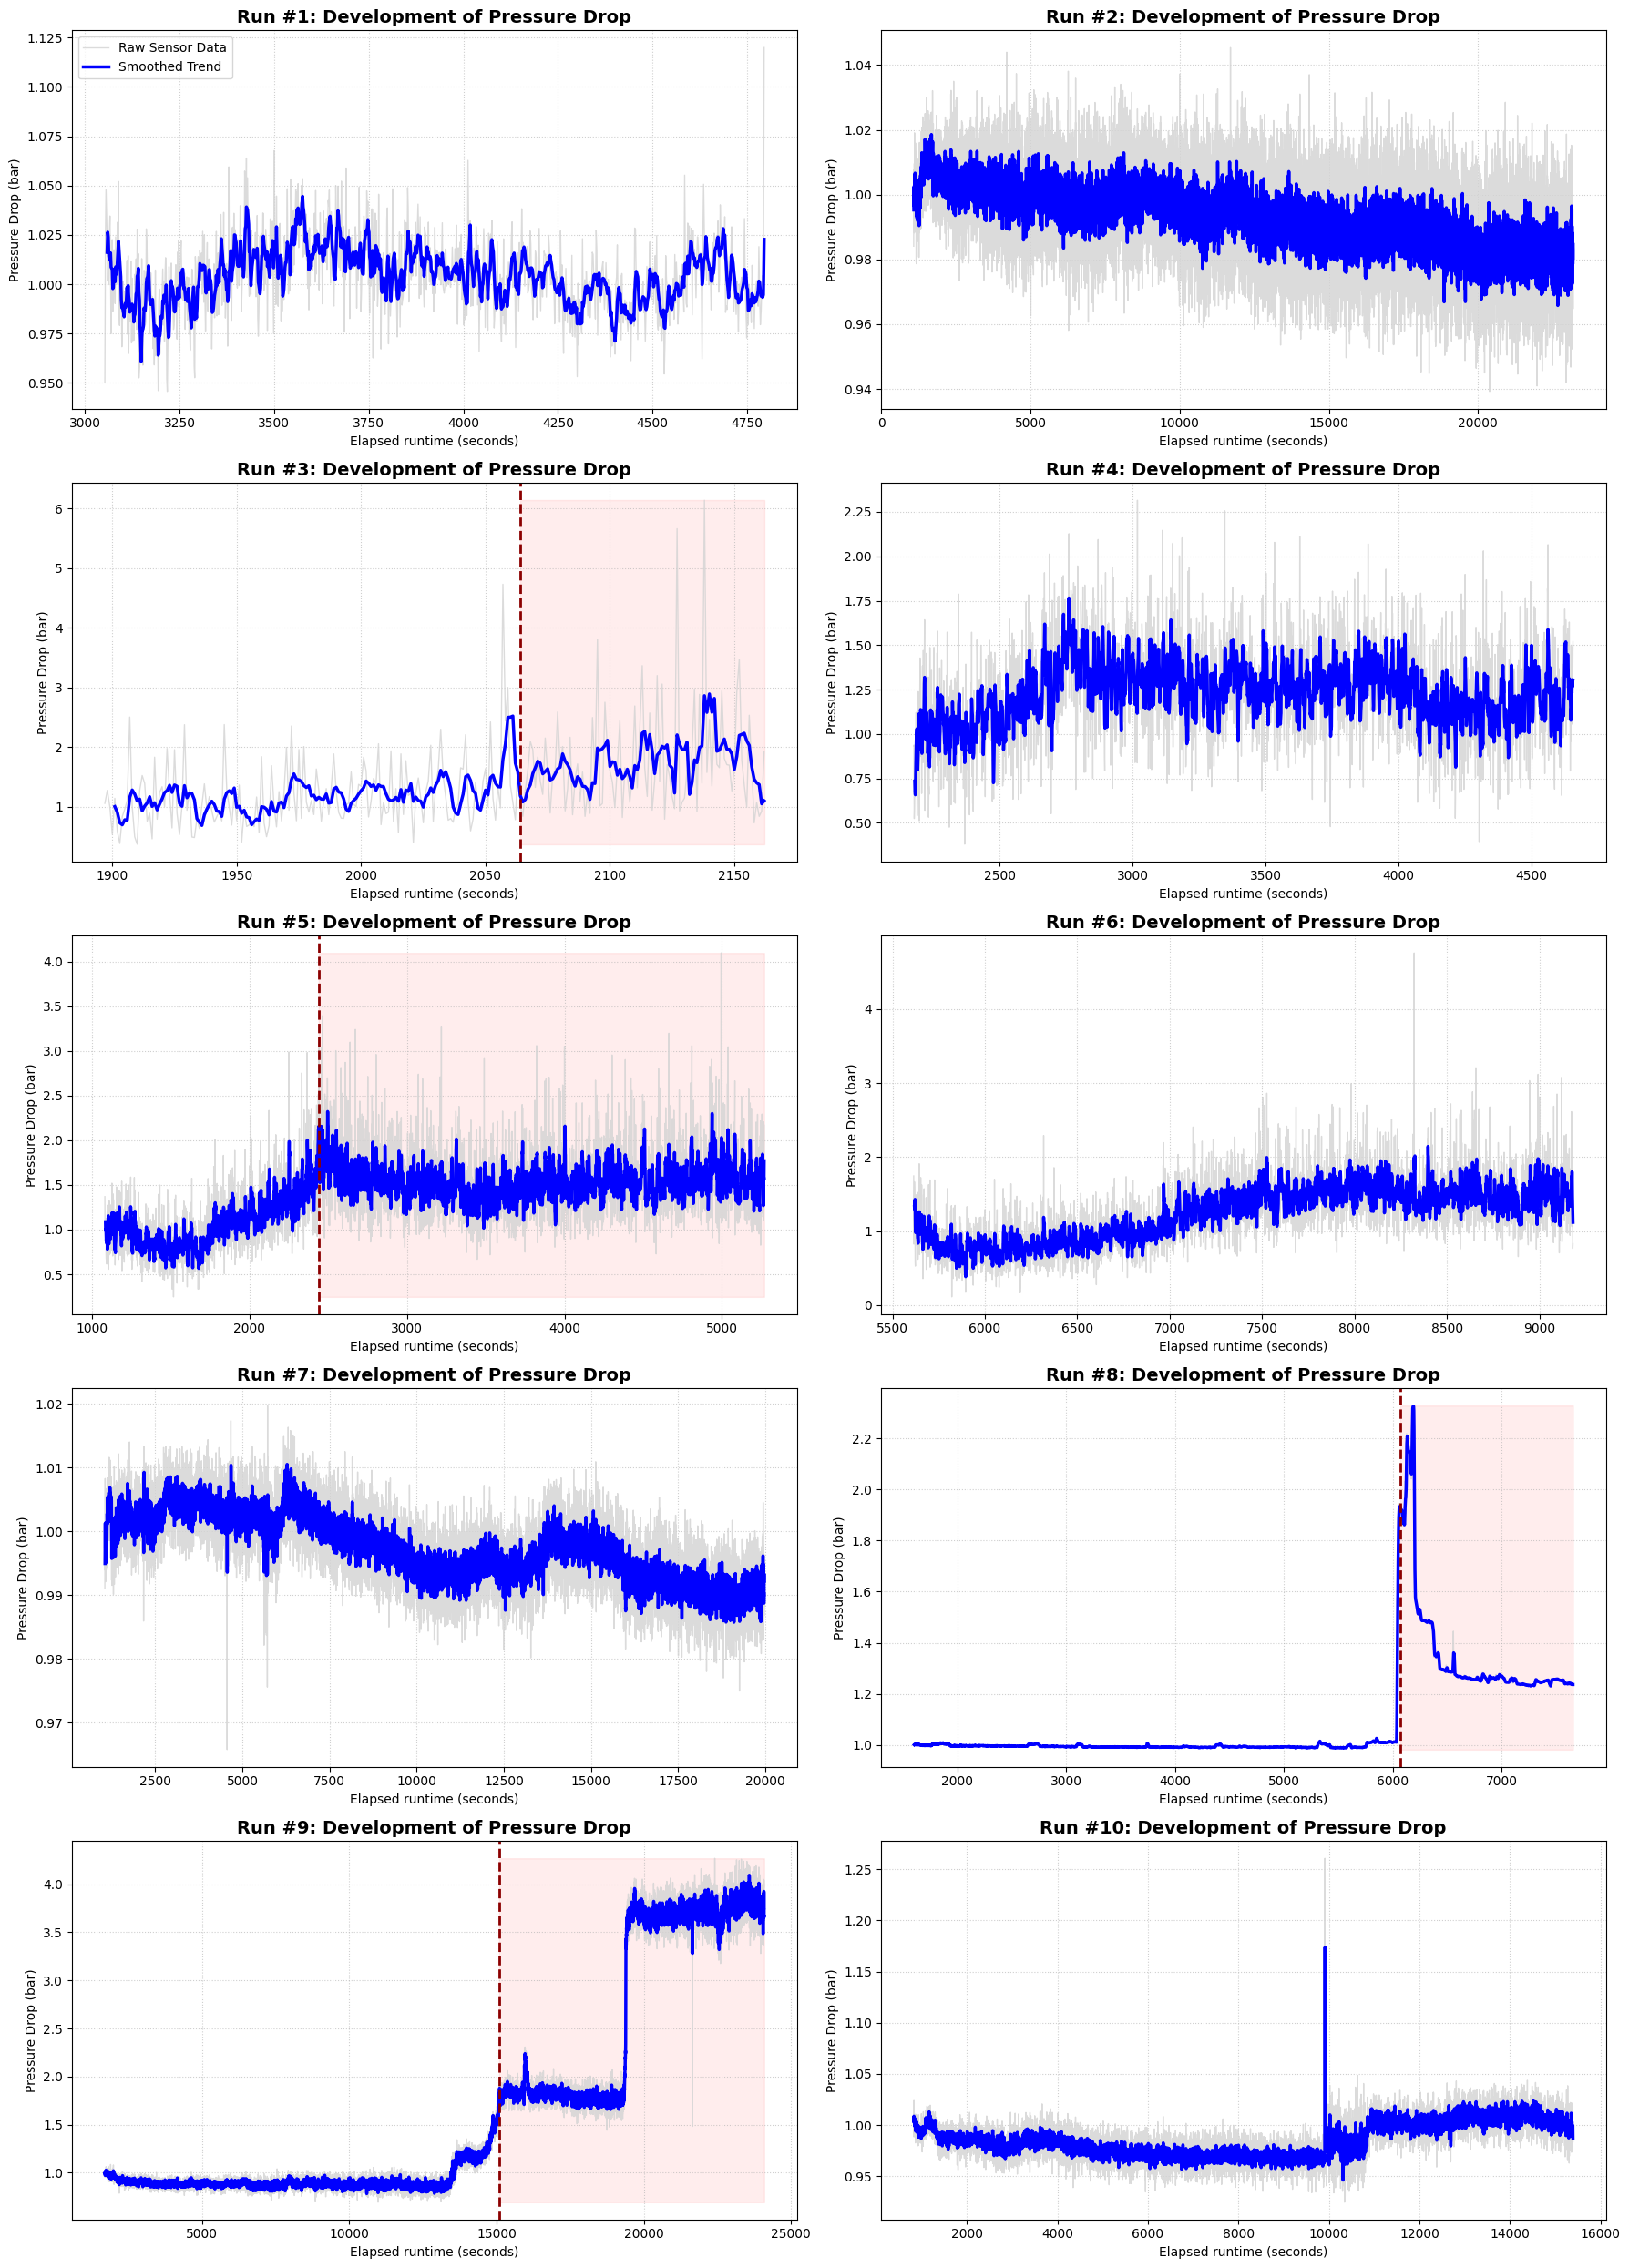

In [296]:
plot_smoothed_plug_trends(no_plug_dfs_labeled)

In [ ]:
"""all_runs = []

for i, df in enumerate(no_plug_dfs_labeled):
    tmpdf = df.copy()
    tmpdf['Run_ID'] = f'No-Plug_Run_{i+1}'
    tmpdf['Is_Plug_File'] = 0
    all_runs.append(tmpdf)

for i, df in enumerate(plug_dfs_labeled):
    tmpdf = df.copy()
    tmpdf['Run_ID'] = f'Plug_Run_{i+1}'
    tmpdf['Is_Plug_File'] = 1
    all_runs.append(tmpdf)

master_df = pd.concat(all_runs, axis=0).reset_index(drop=True)
"""

In [ ]:
#master_df.to_csv('../data/concat/standardized_dataset.csv', index=False)

In [ ]:
"""runs = []
for i, df in enumerate(plug_dfs_labeled):
    tmpdf = df.copy()
    tmpdf['Run_ID'] = f'Plug_Run_{i+1}'
    tmpdf['Is_Plug_File'] = 1
    runs.append(tmpdf)

runs_df = pd.concat(runs, axis=0).reset_index(drop=True)
runs_df.to_csv('../data/concat/plug_only_labeled.csv', index=False)"""